# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
Emily was a quiet woman who rarely spoke to strangers
she worked as a bartender in a small town
ever since she met her boyfriend she began to open up
she started talking freely and laughing more often
her boyfriend worked at the local bank
one day a man with tattoos walked into the bar
the tattoos looked like the marks of an old gang
he kept coming back for several days in a row
the town had suffered gang violence years before
she feared a new gang war was brewing
she feared the man was planning to rob the bank
she left work early that day
the sky was dark with heavy rainclouds
when she reached home the lights were off
a gun was pressed against her head
she could not see who was holding it
the man told her to sit down
she obeyed and turned on the light
she saw his tattoos and his burned scars
she realized she had seen him before
he said he knew that she recognized him
she began to panic
he said he had a story to tell her
he said he had one question first
he asked how well she really knew her fiance
she said her fiance was everything to her
he had lifted her up when she had no one
her mother had died and her father had left her
he had been the only person she could rely on
the man said then you do not know his past
he told her about the gang war of the past
her fiance had belonged to the rival faction
the man himself had once loved a woman named Mary
he had left the gang to be with her
on their wedding day the rival faction set the church on fire
her fiance was one of the men who started that fire
the burned church still stands on the edge of town
Mary died in the fire despite his efforts to save her
his scars were proof of that day
he said Mary had been the light in his darkness
he asked her again what a perfect revenge would look like
he asked if killing his enemy's bride would bring him peace
she told him he could kill her if he wished
she asked if that would truly bring him peace
she admitted her fiance had a dark past
she said she chose to see who he had become
she begged him to spare her fiance even if he killed her
two gunshots rang out in the dark house
it was never revealed whether she survived
the man walked to the burned church at the edge of town
he stood before a grave and spoke softly
he said he hoped Mary was not angry with him
he said he hoped she had found peace
he wondered if she would have wanted a different outcome
he said he wondered still
'''
print(corpus)


Emily was a quiet woman who rarely spoke to strangers
she worked as a bartender in a small town
ever since she met her boyfriend she began to open up
she started talking freely and laughing more often
her boyfriend worked at the local bank
one day a man with tattoos walked into the bar
the tattoos looked like the marks of an old gang
he kept coming back for several days in a row
the town had suffered gang violence years before
she feared a new gang war was brewing
she feared the man was planning to rob the bank
she left work early that day
the sky was dark with heavy rainclouds
when she reached home the lights were off
a gun was pressed against her head
she could not see who was holding it
the man told her to sit down
she obeyed and turned on the light
she saw his tattoos and his burned scars
she realized she had seen him before
he said he knew that she recognized him
she began to panic
he said he had a story to tell her
he said he had one question first
he asked how well she really k

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
lines = corpus.split('\n')
lines = [line for line in lines if line.strip() != '']

tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 202
X shape: (433, 11)
y shape: (433,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 256), # removed input_length parameter as it is deprecated
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

rnn_model.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, callbacks=[early_stop], verbose=1)
print("Vanilla RNN training completed")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0370 - loss: 5.2521      
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0531 - loss: 4.9490     
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0693 - loss: 4.7542 
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0947 - loss: 4.5950 
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1293 - loss: 4.4297 
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1363 - loss: 4.2648 
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2356 - loss: 4.0327 
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2679 - loss: 3.7985 
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3233 - loss: 3.5412 
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4042 - loss: 3.2645 
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4873 - loss: 2.9829 
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 256),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

lstm_model.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, callbacks=[early_stop], verbose=1)
print("LSTM training completed")

Epoch 1/200


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0277 - loss: 5.2805      
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0485 - loss: 5.0067 
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0485 - loss: 4.8785     
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0508 - loss: 4.8005 
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0716 - loss: 4.7296 
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0739 - loss: 4.6566 
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0831 - loss: 4.5567 
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1132 - loss: 4.4577 
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1201 - loss: 4.3136 
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1363 - loss: 4.1613 
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1547 - loss: 3.9791 
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 256),
    GRU(128),
    Dense(total_words, activation='softmax')
])

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

gru_model.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, callbacks=[early_stop], verbose=1)
print("GRU training completed")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0300 - loss: 5.2992       
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0831 - loss: 5.1574 
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0554 - loss: 4.8737 
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0647 - loss: 4.7305 
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0970 - loss: 4.5974     
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1339 - loss: 4.4275 
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1640 - loss: 4.2339 
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1917 - loss: 4.0059 
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2240 - loss: 3.7520 
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2540 - loss: 3.4851 
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3118 - loss: 3.2175 
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s

## 📉 Compare Training Loss

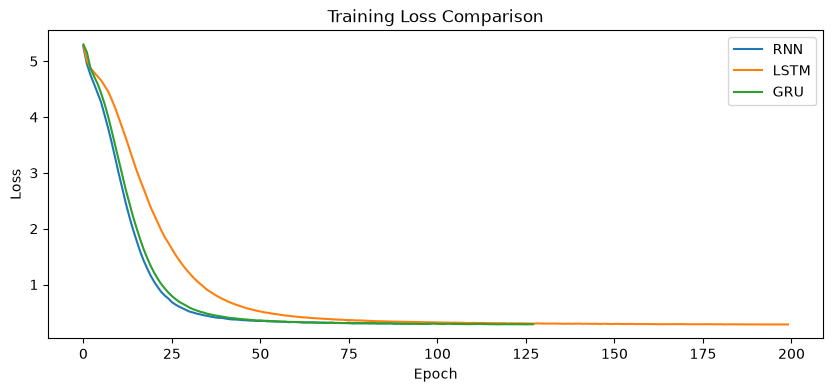

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [21]:
def generate_text(model, seed_text, next_words=10, temperature=0.9):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        preds = model.predict(token_list, verbose=0)[0]
        
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        predicted = np.random.choice(len(preds), p=preds)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [26]:
print("RNN :", generate_text(rnn_model, "he asked her again what", 20))
print("LSTM:", generate_text(lstm_model, "he asked her again what", 20))
print("GRU :", generate_text(gru_model, "he asked her again what", 20))

RNN : he asked her again what a perfect revenge would look like a bartender seen a look killing his enemy's bride would bring him peace open
LSTM: he asked her again what a perfect revenge would look like worked story town old gang angry feared only knew town had seen her save
GRU : he asked her again what a perfect revenge would look like truly bring him peace peace look like a different outcome bring him tattoos peace


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**